<a href="https://colab.research.google.com/github/nomanabdullah04/Natural-Language-Processing-NLP-/blob/main/Text_Processing_Bag_of_Word_Practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd


In [58]:
message=pd.read_csv('/content/SMSSpamCollection', sep='\t', names=['labels','message'])

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
message.head()

,labels,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [61]:
from nltk import corpus
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
import re
wnl = WordNetLemmatizer()


corpus=[]
for i in range(0,len(message)):
  review=re.sub('[^a-zA-Z]',' ',message['message'][i])
  review=review.lower()
  review=review.split()
  review=[wnl.lemmatize(word) for word in review if word not in stopwords.words('english')]
  review=' '.join(review)
  corpus.append(review)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [62]:
corpus

['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
 'ok lar joking wif u oni',
 'free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply',
 'u dun say early hor u c already say',
 'nah think go usf life around though',
 'freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv',
 'even brother like speak treat like aid patent',
 'per request melle melle oru minnaminunginte nurungu vettam set callertune caller press copy friend callertune',
 'winner valued network customer selected receivea prize reward claim call claim code kl valid hour',
 'mobile month u r entitled update latest colour mobile camera free call mobile update co free',
 'gonna home soon want talk stuff anymore tonight k cried enough today',
 'six chance win cash pound txt csh send cost p day day tsandcs apply reply hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd pobox ldnw rw'

#  Scikit-Learn API Reference: CountVectorizer Engine

## 1. Class Architecture & Algorithmic Blueprint

`CountVectorizer` is scikit-learn's premier class for transforming raw, unstructured text document arrays into numerical feature matrices. Natively, it runs an internal textual pipeline that executes **Tokenization**, **Lowercasing**, **Stop-Word Removal**, and **Frequency Analysis** before returning a highly compressed `scipy.sparse.csr_array` (Compressed Sparse Row matrix) to optimize memory storage.

### Mathematical Constructor Definition
```python
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    *,
    input='content', encoding='utf-8', decode_error='strict',
    strip_accents=None, lowercase=True, preprocessor=None,
    tokenizer=None, stop_words=None, token_pattern='(?u)\\b\\w\\w+\\b',
    ngram_range=(1, 1), analyzer='word', max_df=1.0, min_df=1,
    max_features=None, vocabulary=None, binary=False,
    dtype=<class 'numpy.int64'>
)
```

---

## 2. Critical Configuration Parameter Matrix

To optimize `CountVectorizer` performance and avoid memory failure inside your Google Colab runtime, you must tune its signature arguments:

| Hyperparameter | Accepted Types | Production Behavior & Core Application |
| :--- | :--- | :--- |
| **`lowercase`** | `bool` (Default: `True`) | Converts all input characters to lowercase before tokenization loops execute. |
| **`binary`** | `bool` (Default: `False`) | If set to `True`, it forces all non-zero term frequency integer counts down to a boolean `1`. Essential for **Binary Bag-of-Words** profiles. |
| **`stop_words`** | `{'english'}`, `list`, or `None` | Removes common words. While `'english'` utilizes scikit-learn's built-in list, passing a custom Python `list` offers precise control over sentiment-bearing tokens (e.g., keeping *'not'*). |
| **`ngram_range`** | `tuple (min_n, max_n)` | Bounds word combinations. `(1, 1)` targets unigrams; `(1, 2)` extracts individual words plus contiguous pairs (bigrams) to preserve phrases. |
| **`max_df` / `min_df`** | `float` \([0.0, 1.0]\) or `int` | **Frequency Cut-offs.** `max_df=0.95` drops tokens present in more than 95% of documents (corpus-specific noise); `min_df=2` drops words appearing only once. |
| **`max_features`** | `int` or `None` | Imposes a strict dimensionality ceiling. Selects only the top N highest-frequency tokens across the corpus, preventing explosive sparse matrix columns. |

---

## 3. Production Pipeline Execution Code (Google Colab Code Cell)

Copy and run this complete script in the code cell directly following this text cell to verify standard vs. binary encoding transformations using scikit-learn.

```python
# =====================================================================
# STEP 1: LOAD CORE STACK & DEFINE RAW INTERACTION TEXT CORPUS
# =====================================================================
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Sample documents mirroring common text structures and repetitions
corpus = [
    "He is a good boy",
    "She is a good girl",
    "Boy and girl are good"
]

# =====================================================================
# STEP 2: INSTANTIATE AND FIT STANDARD TERM FREQUENCY VECTORIZER
# =====================================================================
# Configuration incorporates structural lowercasing and basic English filter
standard_vectorizer = CountVectorizer(lowercase=True, stop_words='english')
standard_sparse_matrix = standard_vectorizer.fit_transform(corpus)

# Extract vocabulary index maps
vocab_columns = standard_vectorizer.get_feature_names_out()

# Convert sparse matrix array back to human-readable Pandas DataFrame
df_standard = pd.DataFrame(standard_sparse_matrix.toarray(), columns=vocab_columns)
df_standard['Document_Source'] = corpus

# =====================================================================
# STEP 3: INSTANTIATE AND FIT PRESENCE/ABSENCE BINARY VECTORIZER
# =====================================================================
# Activating binary=True clips raw frequencies to a boolean [0, 1] range
binary_vectorizer = CountVectorizer(lowercase=True, stop_words='english', binary=True)
binary_sparse_matrix = binary_vectorizer.fit_transform(corpus)

df_binary = pd.DataFrame(binary_sparse_matrix.toarray(), columns=vocab_columns)
df_binary['Document_Source'] = corpus

# =====================================================================
# STEP 4: DIAGNOSTIC PIPELINE OUTPUT VERIFICATION
# =====================================================================
print("--- EXTRACTED LEXICON VOCABULARY MAPPING ---")
print(standard_vectorizer.vocabulary_)
print("\n--- STANDARD COUNT VECTORIZER MATRIX (TERM FREQUENCIES) ---")
display(df_standard[['Document_Source'] + list(vocab_columns)])

print("\n--- BINARY COUNT VECTORIZER MATRIX (PRESENCE / ABSENCE) ---")
display(df_binary[['Document_Source'] + list(vocab_columns)])
```

---

## 4. Key Properties & Internal Attributes

After calling `.fit()` or `.fit_transform()` on text data arrays, the instance dynamically records internal state attributes:
* **`vocabulary_`:** A dictionary mapping unique string tokens to integer column indices (e.g., `{'good': 2, 'boy': 0, 'girl': 1}`).
* **`fixed_vocabulary_`:** Boolean flag marking whether a hardcoded, predefined external dictionary was assigned by the user prior to training.


In [63]:
#Aplly bag of words
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=100,binary=True)
X=cv.fit_transform(corpus).toarray()


import numpy as np
np.set_printoptions(edgeitems=30,linewidth=1000,formatter=dict(float=lambda x: f"{x:.2e}"))
print(X)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 ... 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ... 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [64]:
cv

CountVectorizer(binary=True, max_features=100)

In [65]:
X.shape

(5572, 100)

In [66]:
X

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0

#   N-gram Contextual Vectorization


## 1. Core Architecture & Mathematical Foundations

In Natural Language Processing (NLP), standard Bag-of-Words (Unigrams) processes words in absolute isolation. This creates a severe **Context Blind Spot** where grammatical negation is completely lost. **N-grams** resolve this by grouping a contiguous sequence of n items from a given sample of text or speech, allowing the vector space to capture localized phrases and sequence logic.

### A. The N-gram Taxonomy
* **Unigram (n=1):** Single tokens evaluated independently (e.g., `["food", "not", "good"]`).
* **Bigram (n=2):** Bounded contiguous pairs of adjacent tokens (e.g., `["food good", "food not", "not good"]`).
* **Trigram (n=3):** Bounded contiguous triplets of adjacent tokens (e.g., `["food is good", "is not good"]`).

### B. The Negation Failure Matrix
Consider the classic lecture board example utilizing standard Unigrams after stopword stripping (`the`, `is` removed):
* **Sentence 1 (S₁):** `"The food is good"` \(\longrightarrow\) `['food', 'good']`
* **Sentence 2 (S₂):** `"The food is not good"` \(\longrightarrow\) `['food', 'not', 'good']`

Under a standard vectorizer mapping matrix, S₁ and S₂ score identically across the `food` and `good` columns. A basic machine learning classifier will struggle to differentiate their opposite meanings because the crucial context link between `not` and `good` is completely broken.

---

## 2. Step-by-Step Data Transformation

To retain context parameters, the sentences transform mechanically through a combined Unigram + Bigram feature space engine.

### 🔹 Step 1: Vocabulary Extraction & Column Mappings
The algorithm scans the text corpus to build an expanded vocabulary index containing both single tokens and joint text combinations:
* **Unigram Mappings:** `food`, `not`, `good`
* **Bigram Mappings:** `food good` (from S₁), `food not` (from S₂), `not good` (from S₂)

\[\text{Unified Feature Subspace (V)} = [\text{'food'}, \text{'not'}, \text{'good'}, \text{'food good'}, \text{'food not'}, \text{'not good'}]\]
\[\text{Total Feature Dimensions } (\lvert V \rvert) = 6\]

### 🔹 Step 2: Numerical Matrix Profiling
Every document maps to an index row matching the specific layout of token occurrences:

* **Vector S₁:** Maps a `1` to `food`, `good`, and the bigram `food good`. It enters `0` for any missing parameters.
* **Vector S₂:** Maps a `1` to `food`, `not`, `good`, `food not`, and `not good`. It enters `0` for `food good`.

---

## 3. Scikit-Learn API Implementation (`CountVectorizer`)

To execute this exact combined structure inside a Google Colab notebook, configure the `ngram_range` parameter within the scikit-learn framework.

```python
# =====================================================================
# STEP 1: IMPORT STACK & DEFINE NEGATION TEST CORPUS
# =====================================================================
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    "The food is good",
    "The food is not good"
]

# =====================================================================
# STEP 2: INITIALIZE VECTORIZER WITH EXTENDED N-GRAM RANGE
# =====================================================================
# ngram_range=(1, 2) extracts BOTH individual words (unigrams) and pairs (bigrams)
# Note: Custom stop_words can be provided, but keeping default to capture 'is not' structures
vectorizer = CountVectorizer(ngram_range=(1, 2), token_pattern=r'(?u)\b\w+\b')
sparse_matrix = vectorizer.fit_transform(corpus)

# Extract column index definitions
feature_names = vectorizer.get_feature_names_out()

# =====================================================================
# STEP 3: CONVERT MATRIX FOR DIAGNOSTIC TESTING
# =====================================================================
df_ngrams = pd.DataFrame(sparse_matrix.toarray(), columns=feature_names)
df_ngrams['Original_Source'] = corpus

print("--- EXPLICIT N-GRAM COMPRESSED MATRIX OUTPUT ---")
display(df_ngrams[['Original_Source'] + list(feature_names)])
```

---

## 4. Summary of Strategic Trade-offs

###  Advantages (Pros)
* **Preserves Local Word Order Natively:** Successfully captures modifier structures and phrases like *"not good"*, preventing catastrophic sentiment reversal errors.
* **Highly Discriminative Features:** Gives classification algorithms high-value phrase pairs that heavily boost accuracy scores on sentiment analysis.
* **Flexible Parametric Scaling:** Easily adjusts via `ngram_range` to scan wide windows of context without restructuring data frameworks.

###  Disadvantages (Cons)
* **Explosive Feature Dimensionality:** As $n$ increases, the unique vocabulary combination size explodes exponentially, leading to severe memory constraints.
* **Extreme Matrix Sparsity:** The overwhelming majority of the generated matrix cells will contain zeros, which can cause model thrashing or overfitting.
* **High Risk of Overfitting:** The machine learning model may over-index on hyper-specific phrase pairs found only in the training set, failing to generalize to new test data.
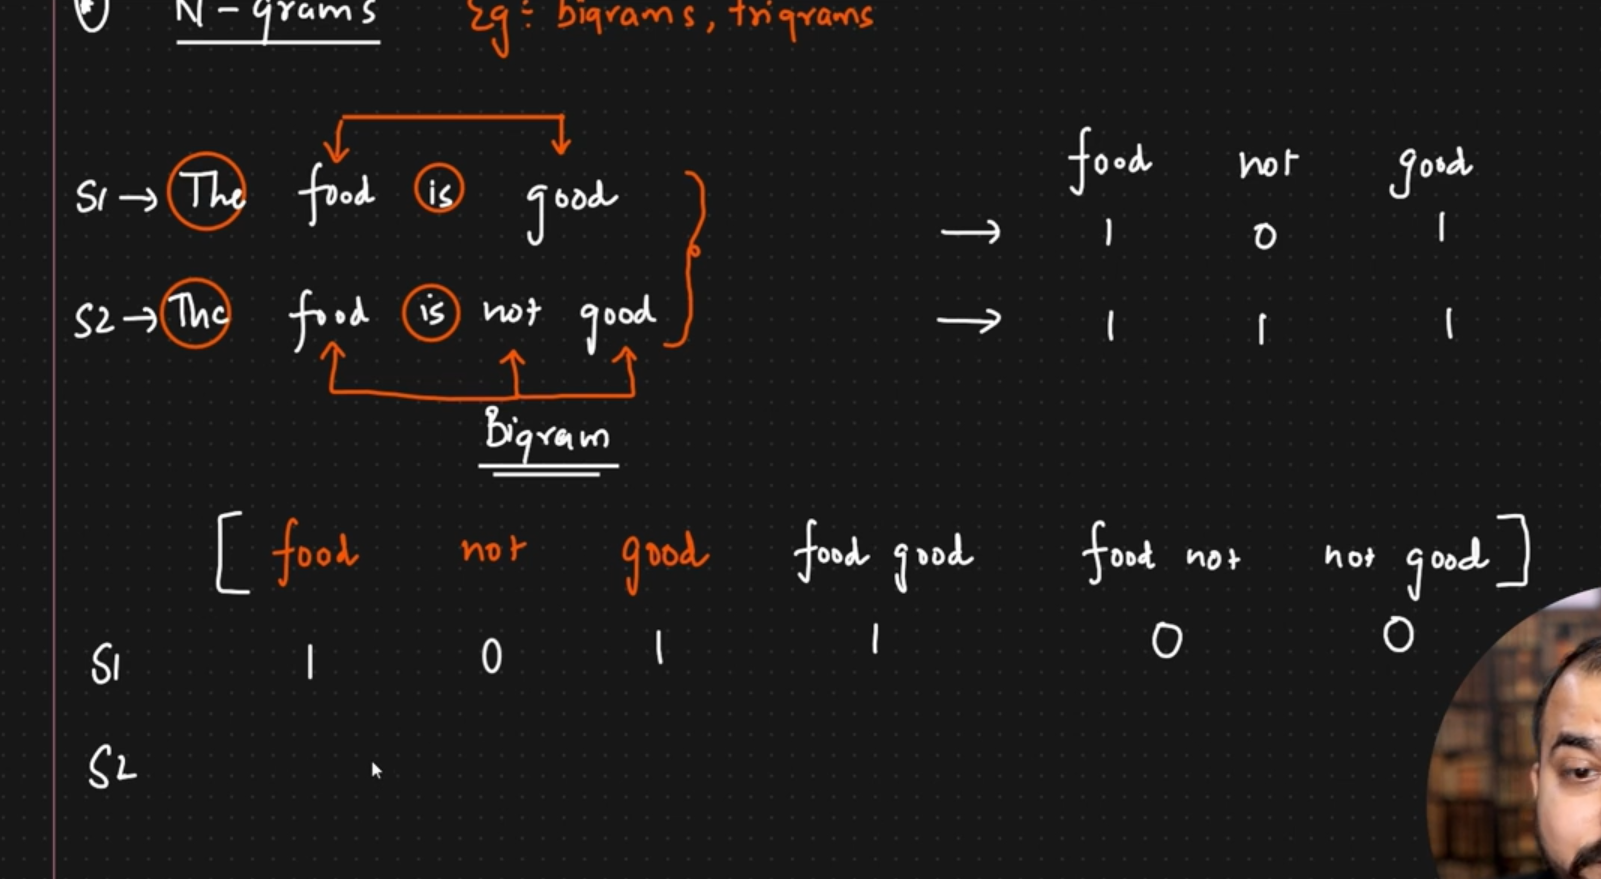

In [67]:
cv.vocabulary_

{'go': np.int64(23),
 'great': np.int64(27),
 'got': np.int64(26),
 'wat': np.int64(90),
 'ok': np.int64(59),
 'free': np.int64(19),
 'win': np.int64(94),
 'text': np.int64(79),
 'txt': np.int64(86),
 'say': np.int64(70),
 'already': np.int64(0),
 'think': np.int64(82),
 'life': np.int64(39),
 'hey': np.int64(30),
 'week': np.int64(92),
 'back': np.int64(6),
 'like': np.int64(40),
 'still': np.int64(75),
 'send': np.int64(72),
 'friend': np.int64(20),
 'prize': np.int64(65),
 'claim': np.int64(10),
 'call': np.int64(7),
 'mobile': np.int64(50),
 'co': np.int64(11),
 'home': np.int64(32),
 'want': np.int64(89),
 'today': np.int64(84),
 'cash': np.int64(9),
 'day': np.int64(15),
 'reply': np.int64(67),
 'www': np.int64(96),
 'right': np.int64(68),
 'take': np.int64(77),
 'time': np.int64(83),
 'message': np.int64(47),
 'com': np.int64(12),
 'oh': np.int64(58),
 'yes': np.int64(99),
 'make': np.int64(45),
 'way': np.int64(91),
 'dont': np.int64(17),
 'miss': np.int64(49),
 'ur': np.int64(

In [68]:
#Apply bigrams
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=500,binary=True,ngram_range=(2,2))
Y=cv.fit_transform(corpus).toarray()

In [69]:
Y

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0

In [70]:
cv.vocabulary_

{'free entry': np.int64(127),
 'rate apply': np.int64(338),
 'per request': np.int64(308),
 'callertune caller': np.int64(43),
 'caller press': np.int64(41),
 'friend callertune': np.int64(131),
 'claim call': np.int64(56),
 'call claim': np.int64(24),
 'claim code': np.int64(57),
 'entitled update': np.int64(114),
 'update latest': np.int64(435),
 'latest colour': np.int64(211),
 'free call': np.int64(125),
 'call mobile': np.int64(32),
 'mobile update': np.int64(263),
 'chance win': np.int64(55),
 'win cash': np.int64(481),
 'reply hl': np.int64(344),
 'hl info': np.int64(185),
 'txt word': np.int64(430),
 'dont miss': np.int64(104),
 'ha ha': np.int64(173),
 'let know': np.int64(217),
 'feel like': np.int64(119),
 'yeah got': np.int64(497),
 'tell anything': np.int64(401),
 'mobile charged': np.int64(259),
 'go home': np.int64(149),
 'anything lor': np.int64(4),
 'want need': np.int64(469),
 'call reply': np.int64(36),
 'nokia mobile': np.int64(289),
 'mobile free': np.int64(260),
 